Total Circular velocity at 8 kpc (MOND) = 241.4 km/s
Enclosed baryonic mass at 200 kpc = 9.15e+10 Msun (should be 9.15e10)


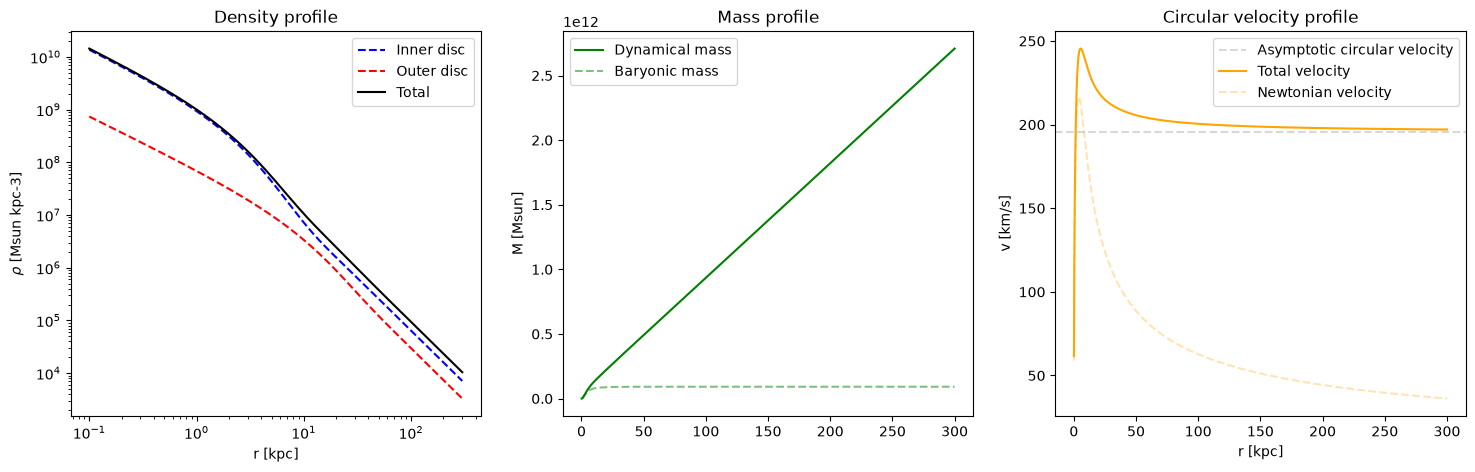

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#constants (hopefully correct)
G         = 4.30091e-3  #pc/M_sol/km/s**2 
a0        = 3.703 #(km/s**2)/pc   
G_kpc     = G * 1e-3 #kpc/M_sol/km/s**2    
a0_kpc    = a0 * 1e3 #(km/s**2)/kpc   

#helper functions
def nu_mond(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r, rd)
    return 0.5 + np.sqrt(0.25 + 1.0/y)

def f(r, rd):
    return 1 - np.exp(-r/rd)*(1 + r/rd)

def df_dr(r, rd):
    return r/(rd**2)* np.exp(-r/rd)

def alpha(M_tot, r):
    return G_kpc*M_tot/(a0_kpc * r**2)

def dnu_dy(M_tot, r, rd):
    y = alpha(M_tot, r) * f(r,rd)
    return -1/(2*y**2*np.sqrt(1/4 + 1/y))

def dnu_dr(M_tot, r, rd):
    dndy = dnu_dy(M_tot, r, rd)
    a = alpha(M_tot, r)
    dfdr = df_dr(r, rd)
    return dndy * a * (dfdr - 2*f(r, rd)/r)

def dMc_dr(M_tot, r, rd):
    dfdr = df_dr(r, rd)
    return M_tot*(f(r, rd) * dnu_dr(M_tot, r, rd) + nu_mond(M_tot, r, rd) * dfdr)

#analytical density profile
def rho_ana(M_tot, r, rd):
    dM_dr = dMc_dr(M_tot, r, rd)
    return 1/(4*np.pi*r**2)* dM_dr

M_MW       = 9.15e10             # Msun — total baryonic mass
f_inner    = 0.8236              # fraction in inner component
f_outer    = 0.1764              # fraction in outer component
Rd_inner   = 1.29/0.6                # kpc AT Z=0???
Rd_outer   = 4.20/0.6                # kpc AT Z=0???

M_inner    = f_inner * M_MW      # 7.54e10 Msun
M_outer    = f_outer * M_MW      # 1.61e10 Msun

r_grid = np.geomspace(0.1, 300, 1000)

def nu(y):
    return 0.5 + np.sqrt(0.25 + 1.0 / np.maximum(y, 1e-30))

M_b_inner = M_inner * f(r_grid, Rd_inner)
M_b_outer = M_outer * f(r_grid, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r_grid**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
vc        = np.sqrt(G_kpc * M_c / r_grid)
vc_newt   = np.sqrt(G_kpc * M_b_total / r_grid)
print(f"Total Circular velocity at 8 kpc (MOND) = {np.interp(8, r_grid, vc):.1f} km/s")
print(f"Enclosed baryonic mass at 200 kpc = {np.interp(200, r_grid, M_b_total):.2e} Msun (should be 9.15e10)")
rho_ana_1 = rho_ana(M_inner, r_grid, Rd_inner)
rho_ana_2 = rho_ana(M_outer, r_grid, Rd_outer)
v_inf_theo = (G_kpc * M_MW * a0_kpc)**0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].loglog(r_grid, rho_ana_1, label="Inner disc", color="blue", ls = "dashed")
axes[0].loglog(r_grid, rho_ana_2, label="Outer disc", color="red", ls ="dashed")
axes[0].loglog(r_grid, rho_ana_1 + rho_ana_2, label="Total", color="black")
axes[0].set_xlabel("r [kpc]")
axes[0].set_ylabel(r"$\rho$ [Msun kpc-3]")
axes[0].set_title("Density profile") 
axes[0].legend()
axes[1].plot(r_grid, M_c, label="Dynamical mass", color="green")
axes[1].plot(r_grid, M_b_total, label="Baryonic mass", color="green",alpha=0.5, ls = "dashed")
axes[1].set_ylabel("M [Msun]")=
axes[1].set_title("Mass profile")
axes[1].legend()
axes[2].axhline(v_inf_theo, ls = "dashed", c  "grey", alpha = 0.3, label="Asymptotic circular velocity")
axes[2].plot(r_grid, vc, label="Total velocity", color="orange")
axes[2].plot(r_grid, vc_newt, label="Newtonian velocity",  color="orange",alpha = 0.3, ls = "dashed")
axes[2].set_xlabel("r [kpc]")
axes[2].set_ylabel("v [km/s]")
axes[2].set_title("Circular velocity profile")
axes[2].legend()

In [1]:
r = 100
M_b_inner = M_inner * f(r, Rd_inner)
M_b_outer = M_outer * f(r, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
print(M_c)
print("vc", np.sqrt(G_kpc * M_c / r))
print("vc", (G_kpc * M_b_total * a0_kpc)**0.25)

NameError: name 'M_inner' is not defined

In [ ]:
r_grid = np.linspace(0,500,1000)
M_b_inner = M_inner * f(r_grid, Rd_inner)
M_b_outer = M_outer * f(r_grid, Rd_outer)
M_b_total = M_b_inner + M_b_outer
gN_total  = G_kpc * M_b_total / r_grid**2
y_total   = gN_total / a0_kpc
nu_total  = nu(y_total)
M_c       = nu_total * M_b_total
vc_grid        = np.sqrt(G_kpc * M_c / r_grid)
vc_theo   = (G_kpc * M_b_total * a0_kpc)**0.25
plt.plot(r_grid, vc_theo, color="red")
plt.plot(r_grid, vc_grid)

NameError: name 'np' is not defined

In [ ]:
import pynbody as pn
s = pn.load("/Users/olgahinke/Desktop/simus/test_analytic_mw/test/output_00001")
print("r units =", s.dm["pos"].units)
print("vel units =", s.dm["vel"].units)
correction = 2.07e+02 #cm/s^-1

/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:846: UserWarning: Using field at offset 9 to distinguish stars. If this is wrong, try editing your config.ini, section [ramses], entry particle-distinguisher.
  warnings.warn(
/Users/olgahinke/venv/masterproject/lib/python3.12/site-packages/pynbody/snapshot/ramses.py:1055: UserWarning: Namelist file either not found or unable to read. Guessing whether run is cosmological from cosmological parameters assuming flat LCDM.
  warnings.warn("Namelist file either not found or unable to read. " +


r units = 3.09e+21 cm
vel units = 2.07e+02 cm s**-1


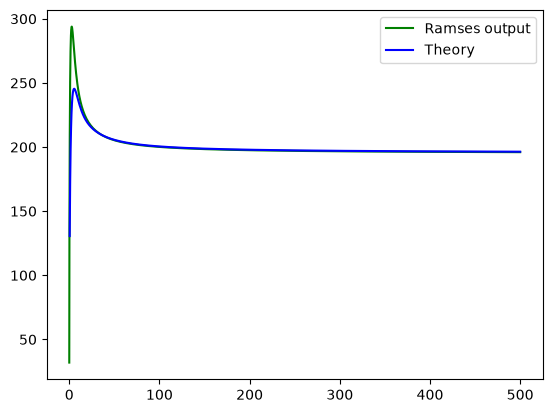

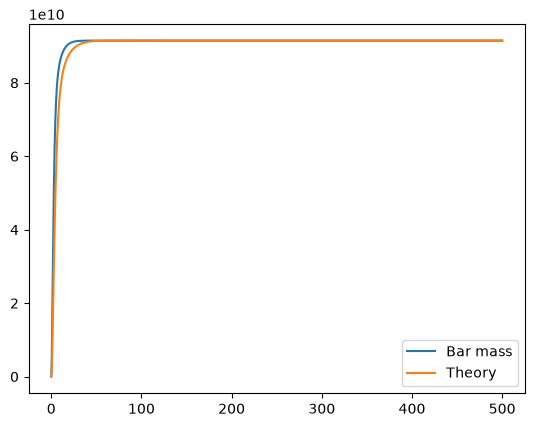

In [ ]:
d = "/Users/olgahinke/Desktop/simus/without_dens/mond_rotation_table.dat"

data = np.loadtxt(d)
r    = data[:, 0]
Mc = data[:, 3]
gN = data[:, 4]
y = data[:, 5]
nu = data[:, 6]
vc    = data[:, 8]
vc_newt    = data[:, 9]
vc_kms =  vc * correction / 1e5
plt.plot(r, vc_kms, label="Ramses output", color="green")
plt.plot(r_grid, vc_grid, label="Theory", color="blue")
plt.legend()
plt.show()
plt.plot(r, Mc, label="Bar mass")
plt.plot(r_grid, M_b_total, label="Theory")
plt.legend()